# EDA - Dataset DNU: tweets_filtrados_combinados
Exploración básica: fechas, volumen total y distribución temporal.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('DNU_Data/tweets_filtrados_combinados.csv', low_memory=False)
print(f'Filas: {len(df):,}  |  Columnas: {df.shape[1]}')
df.head(2)

Filas: 259,752  |  Columnas: 16


,created_at,id,id_str,text,source,truncated,in_reply_to_status_id,in_reply_to_status_id_str,in_reply_to_user_id,quoted_status.place.place_type,quoted_status.place.name,retweeted_status.quoted_status.quoted_status_id,is_retweet,caracteres,text_pp,tokens
0,Fri Mar 05 11:01:46 +0000 2021,1367792447334580225,1367792447334580225,RT @CELS_Argentina: ✅Celebramos la decisión de...,"<a href=""http://twitter.com/download/android"" ...",False,NaN,NaN,NaN,NaN,NaN,NaN,True,140,rt cels_argentina ✅ celebramos la decision del...,"['rt', 'celebramos', 'decision', 'ejecutivo', ..."
1,Fri Mar 05 11:06:31 +0000 2021,1367793643239702529,1367793643239702529,RT @LANACION: Ley de Migraciones: el Gobierno ...,"<a href=""http://twitter.com/download/android"" ...",False,NaN,NaN,NaN,NaN,NaN,NaN,True,139,rt lanacion ley de migraciones el gobierno der...,"['rt', 'lanacion', 'ley', 'migración', 'gobier..."


In [2]:
# Parsear fecha
df['fecha'] = pd.to_datetime(df['created_at'], format='%a %b %d %H:%M:%S +0000 %Y', utc=True)
df['fecha_dia'] = df['fecha'].dt.date

print(f"Primer tweet : {df['fecha'].min()}")
print(f"Último tweet : {df['fecha'].max()}")
print(f"Total tweets : {len(df):,}")
print(f"Rango        : {(df['fecha'].max() - df['fecha'].min()).days} días")

Primer tweet : 2021-03-05 11:01:46+00:00
Último tweet : 2021-03-09 00:02:20+00:00
Total tweets : 259,752
Rango        : 3 días


In [3]:
# Tweets por fecha
por_dia = df.groupby('fecha_dia').size().reset_index(name='tweets')
por_dia['fecha_dia'] = pd.to_datetime(por_dia['fecha_dia'])

print(f'Días con datos: {len(por_dia)}')
print(f'Día con más tweets: {por_dia.loc[por_dia.tweets.idxmax(), "fecha_dia"].date()} ({por_dia.tweets.max():,} tweets)')
print(f'Promedio diario: {por_dia.tweets.mean():,.0f} tweets')
por_dia.sort_values('fecha_dia').head(10)

Días con datos: 5
Día con más tweets: 2021-03-05 (106,851 tweets)
Promedio diario: 51,950 tweets


,fecha_dia,tweets
0,2021-03-05,106851
1,2021-03-06,80224
2,2021-03-07,37339
3,2021-03-08,35160
4,2021-03-09,178


In [4]:
# Tabla completa de tweets por día
por_dia.sort_values('fecha_dia').style.background_gradient(subset=['tweets'], cmap='Blues')

,fecha_dia,tweets
0,2021-03-05 00:00:00,106851
1,2021-03-06 00:00:00,80224
2,2021-03-07 00:00:00,37339
3,2021-03-08 00:00:00,35160
4,2021-03-09 00:00:00,178


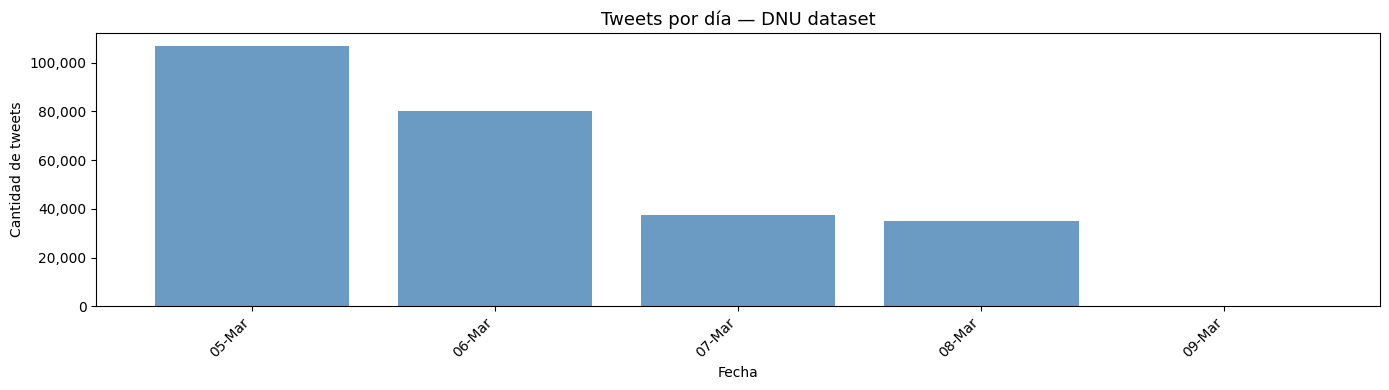

In [5]:
# Gráfico de volumen diario
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(por_dia['fecha_dia'], por_dia['tweets'], color='steelblue', alpha=0.8, width=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha='right')

ax.set_title('Tweets por día — DNU dataset', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de tweets')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('outputs/DNU_tweets_por_dia.png', dpi=150)
plt.show()

---\n## Clasificación de hate speech\nModelo: `piubamas/beto-contextualized-hate-speech`  \nContexto vacío — texto: columna `text` del tweet.

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.notebook import tqdm

MODEL_NAME = "piubamas/beto-contextualized-hate-speech"
BATCH_SIZE = 32
CHECKPOINT_PATH = "DNU_Data/clasificacion_checkpoint.csv"
OUTPUT_PATH = "DNU_Data/tweets_clasificados.csv"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()

id2label = [model.config.id2label[k] for k in range(len(model.config.id2label))]
print(f'Labels del modelo: {id2label}')

Dispositivo: cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: piubamas/beto-contextualized-hate-speech
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Labels del modelo: ['CALLS', 'WOMEN', 'LGBTI', 'RACISM', 'CLASS', 'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL']


In [7]:
def predict_batch(texts, context=""):
    """Clasifica un batch de tweets. Contexto vacío por defecto."""
    contexts = [context] * len(texts)
    encoding = tokenizer(
        texts,
        contexts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )
    inputs = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        output = model(**inputs)

    # preds: (batch_size, num_labels) — True donde logit > 0
    preds = output.logits.detach().cpu().numpy() > 0
    return preds

In [8]:
import os
import numpy as np

# Retomar desde checkpoint si existe
if os.path.exists(CHECKPOINT_PATH):
    df_done = pd.read_csv(CHECKPOINT_PATH)
    start_idx = len(df_done)
    all_preds = df_done[[c for c in df_done.columns if c in id2label]].values.tolist()
    print(f"Retomando desde checkpoint: {start_idx:,} tweets ya procesados")
else:
    start_idx = 0
    all_preds = []
    print("Iniciando clasificación desde cero")

texts = df['text'].fillna("").tolist()
total = len(texts)
CHECKPOINT_EVERY = 5000  # guarda cada 5k tweets

for i in tqdm(range(start_idx, total, BATCH_SIZE), desc="Clasificando tweets"):
    batch = texts[i: i + BATCH_SIZE]
    preds = predict_batch(batch)
    all_preds.extend(preds.tolist())

    # Checkpoint periódico
    if len(all_preds) % CHECKPOINT_EVERY < BATCH_SIZE:
        df_partial = df.iloc[:len(all_preds)].copy()
        for j, label in enumerate(id2label):
            df_partial[label] = [row[j] for row in all_preds]
        df_partial.to_csv(CHECKPOINT_PATH, index=False)

print(f"Clasificación completa: {len(all_preds):,} tweets")

Iniciando clasificación desde cero


Clasificando tweets:   0%|          | 0/8118 [00:00<?, ?it/s]

Clasificación completa: 259,752 tweets


In [9]:
# Agregar predicciones al dataframe y guardar resultado final
for j, label in enumerate(id2label):
    df[label] = [row[j] for row in all_preds]

# Columna con lista de etiquetas activas
df['labels'] = df.apply(lambda row: [l for l in id2label if row[l]], axis=1)
df['n_labels'] = df['labels'].apply(len)

df.to_csv(OUTPUT_PATH, index=False)
print(f"Guardado en: {OUTPUT_PATH}")

print(f"\nDistribución de etiquetas:")
for label in id2label:
    n = df[label].sum()
    print(f"  {label:30s}: {n:>7,}  ({n/len(df)*100:.1f}%)")

print(f"\nTweets sin ninguna etiqueta : {(df['n_labels']==0).sum():,} ({(df['n_labels']==0).mean()*100:.1f}%)")
print(f"Tweets con al menos 1 etiq. : {(df['n_labels']>0).sum():,} ({(df['n_labels']>0).mean()*100:.1f}%)")

Guardado en: DNU_Data/tweets_clasificados.csv

Distribución de etiquetas:
  CALLS                         :   2,022  (0.8%)
  WOMEN                         :   1,938  (0.7%)
  LGBTI                         :     129  (0.0%)
  RACISM                        :   8,962  (3.5%)
  CLASS                         :     936  (0.4%)
  POLITICS                      :   2,756  (1.1%)
  DISABLED                      :     711  (0.3%)
  APPEARANCE                    :   1,077  (0.4%)
  CRIMINAL                      :     741  (0.3%)

Tweets sin ninguna etiqueta : 244,067 (94.0%)
Tweets con al menos 1 etiq. : 15,685 (6.0%)


In [ ]:
df.to_csv("DNU_Data/tweets_clasificados.csv", index=False)    